In [14]:
import scanpy as sc
import matplotlib.pyplot as plt
from scipy import stats
import pandas

In [6]:
adata = sc.read_h5ad('./data/scrna.h5ad')

In [8]:
def plot_stacks(adata, col1, col2, ax=None, orientation='horizontal'):
    df = adata.obs.groupby([col1, col2]).size().reset_index(name='counts')
    df = df[df['counts'] > 0]
    df = df.pivot(index=col1, columns=col2, values='counts')
    if ax is None: ax = plt.gca()
    if orientation=='horizontal': df.plot.barh(stacked=True, ax=ax, color=adata.uns[col2+'_colors'])
    elif orientation=='vertical': df.plot.bar(stacked=True, ax=ax, color=adata.uns[col2+'_colors'])

/tmp/ipykernel_3523885/3409500303.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = adata.obs.groupby([col1, col2]).size().reset_index(name='counts')


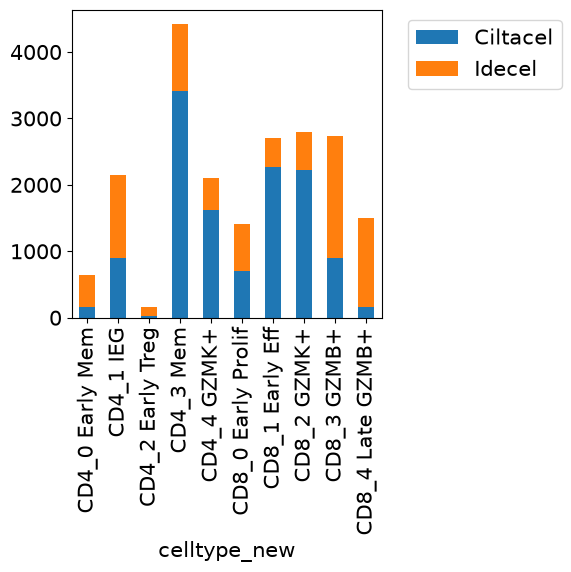

In [10]:
plt.rcParams.update({'font.size': 15})
plt.figure(figsize=(4,4))
plot_stacks(adata, 'celltype_new', 'car', ax=plt.gca(), orientation='vertical')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 

/tmp/ipykernel_3523885/3409500303.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = adata.obs.groupby([col1, col2]).size().reset_index(name='counts')


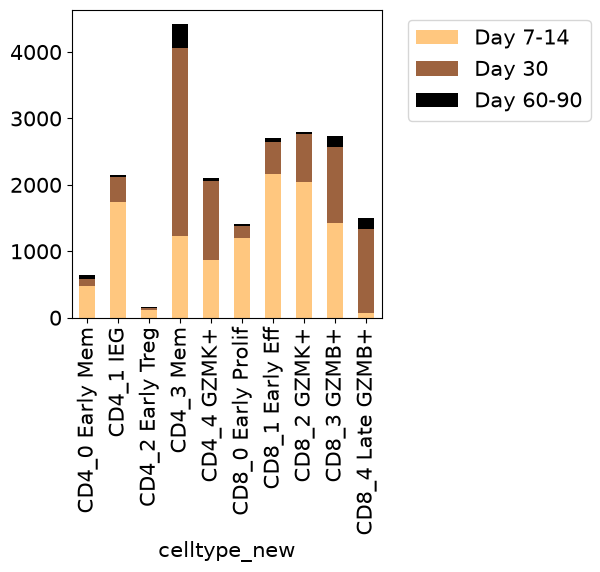

In [11]:
plt.rcParams.update({'font.size': 15})
plt.figure(figsize=(4,4))
plot_stacks(adata, 'celltype_new', 'timepoint_new', ax=plt.gca(), orientation='vertical')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 

/tmp/ipykernel_3523885/3409500303.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = adata.obs.groupby([col1, col2]).size().reset_index(name='counts')


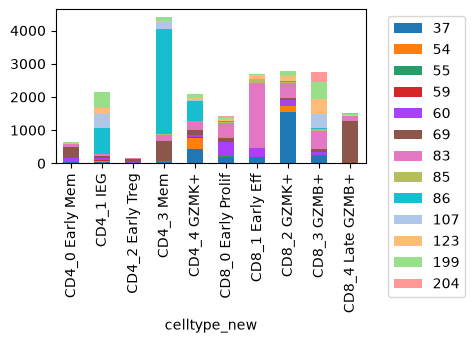

In [12]:
plt.rcParams.update({'font.size': 10})
plt.figure(figsize=(4,2))
plot_stacks(adata, 'celltype_new', 'pt_id', ax=plt.gca(), orientation='vertical')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 

In [18]:
adata_cd4 = adata[adata.obs['celltype_new'].str.startswith('CD4')].copy()
adata_cd8 = adata[adata.obs['celltype_new'].str.startswith('CD8')].copy()

In [32]:
def calc_pvals(adata, score_name, col_name, select_celltype, alternative='two-sided'):
    cols = adata.obs[col_name].unique()
    for i in range(len(cols)):
        if cols[i] == select_celltype: continue
        c1 = adata[adata.obs[col_name]==cols[i]].obs[score_name]
        c2 = adata[adata.obs[col_name]==select_celltype].obs[score_name]
        _,pv = stats.mannwhitneyu(c1, c2, alternative=alternative)
        sgn = "!=" if alternative=='two-sided' else (">" if alternative=='greater' else "<")
        print(cols[i], select_celltype, ":", pv)

In [19]:
genes_rcc = pandas.read_csv("/data1/lesliec/sneha/data/Krishna_ccRCC_T_2021/SuppTblS1A.csv", sep=',', skiprows=1)
cd8_clusters = ['CD8A+ Exhausted', 'CD8A+ Exhausted IEG',
                                            'CD8A+ Proliferating', 'CD8A+ Tissue-resident',
                                            'CD8A+ NK-like']
cd4_clusters = ['CD4+ Naive', 'CD4+ Treg', 'CD4+ Activated IEG', 'CD4+ Effector', 'CD4+ Proliferating']

In [21]:
# CD4+ Effector signature downloaded from SuppTblS1A in Krishna et al., Cancer Cell 2021
# genes = SuppTblS1A[(SuppTblS1A['cluster']=='CD4+ Effector') & (SuppTblS1A['logFC'] > 0.5) & (SuppTblS1A['p_val_adj'] < 1e-10)]['gene'].values[:20]
genes = ['CAPG', 'LGALS1', 'NKG7', 'GZMK', 'GZMA', 'CD8A', 'CCL5', 'ANXA2',
       'S100A4']
c = 'CD4+ Effector'
sc.tl.score_genes(adata_cd4, genes, score_name='Krishna_'+c)

<Axes: ylabel='Krishna_CD4+ Effector'>

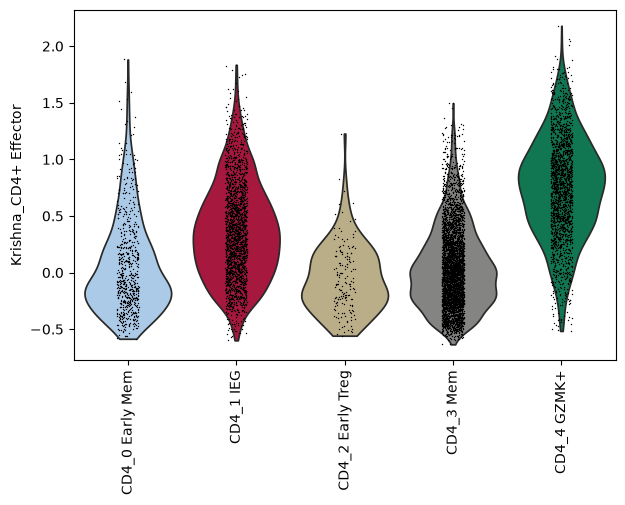

In [23]:
sc.pl.violin(adata_cd4, 'Krishna_'+c,
            groupby='celltype_new', rotation=90, show=False)

In [33]:
calc_pvals(adata_cd4, 'Krishna_'+c, 'celltype_new', 'CD4_4 GZMK+', alternative='two-sided')

CD4_1 IEG CD4_4 GZMK+ : 5.815434733386777e-153
CD4_0 Early Mem CD4_4 GZMK+ : 1.0287414319310413e-172
CD4_3 Mem CD4_4 GZMK+ : 0.0
CD4_2 Early Treg CD4_4 GZMK+ : 2.4198523741570036e-74


In [37]:
# T1 signature downloaded from 41586_2024_8395_MOESM4_ESM.csv in Lan et al., Nature 2025
# genes = tbl_lan[(tbl_lan['cluster']=='T1') & (tbl_lan['logFC'] > 0.5) & (tbl_lan['p_val_adj'] < 1e-10)]['gene'].values[:20]

c = 'T1'
genes = ['GZMK', 'CD74', 'CST7', 'HLA-DRB1', 'CMC1', 'HLA-DRA', 'KLRG1',
       'HLA-DQA1', 'DUSP2', 'HLA-DPB1', 'NKG7', 'SH2D1A', 'HLA-DPA1',
       'PLEK', 'GZMA', 'LYST', 'HLA-DQB1', 'CCL4', 'CCL4L2', 'SAMD3']
sc.tl.score_genes(adata_cd8, genes, score_name='Lan_'+c)

<Axes: ylabel='Lan_T1'>

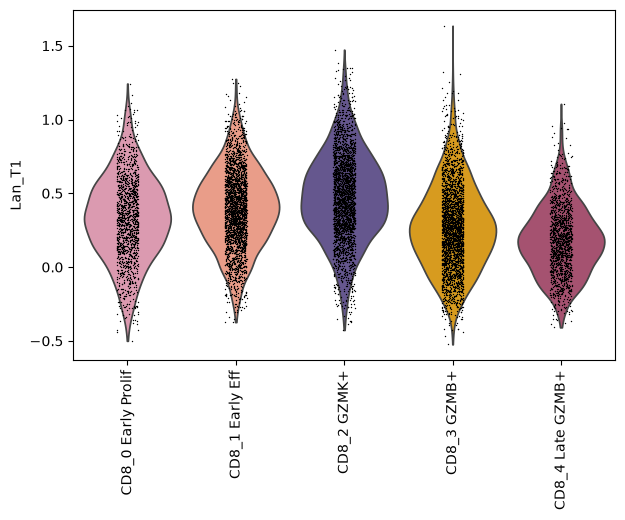

In [38]:
sc.pl.violin(adata_cd8, 'Lan_'+c,
            groupby='celltype_new', rotation=90, show=False)

In [39]:
calc_pvals(adata_cd8, 'Lan_'+c, 'celltype_new', 'CD8_2 GZMK+', alternative='two-sided')

CD8_4 Late GZMB+ CD8_2 GZMK+ : 1.2040565368166672e-207
CD8_3 GZMB+ CD8_2 GZMK+ : 2.9645661475498193e-143
CD8_0 Early Prolif CD8_2 GZMK+ : 1.8267121197570926e-46
CD8_1 Early Eff CD8_2 GZMK+ : 3.173205620280309e-22
